In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def lstsqr(x, y):
    xmean = np.mean(x)
    ymean = np.mean(y)
    mnum = np.sum((x-xmean)*(y-ymean))
    mdem = np.sum((x-xmean)**2)
    m = mnum/mdem
    c = ymean - m*xmean
    return m, c

Function Test with Random Vectors:

In [3]:
X = np.random.rand(5)
Y = np.random.rand(5)

In [4]:
m, c = lstsqr(X, Y)
print(f"Calculated Slope: {m} Calculates Intercept: {c}")

Calculated Slope: -0.3510404328828096 Calculates Intercept: 0.7508585216707585


In [5]:
x1 = np.linspace(min(X), max(X), 100)
x1 = np.sort(x1)
y1 = m*x1+c

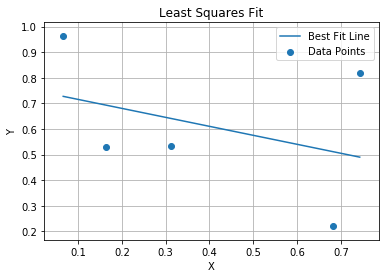

In [6]:
plt.figure()
plt.xlabel("X")
plt.ylabel("Y")
plt.scatter(X, Y, label='Data Points')
plt.plot(x1, y1, label='Best Fit Line')
plt.grid(True)
plt.legend()
plt.title("Least Squares Fit")
plt.show()

Function appears to work correctly

Comparing my Function to Numpy Function with Arbitrary Function + error:

In [7]:
x = np.arange(0, 1.01, 0.01)
m = 2
b = 3
error = np.random.uniform(-1, 1, len(x))
y = m*x+b+error

Numpy Least Square Fit:

In [8]:
A = np.vstack([x, np.ones(len(x))]).T
m1, c1 = np.linalg.lstsq(A, y, rcond=None)[0]
print(f"Calculated Slope: {m1}, Calculated Intercept: {c1}")
y1 = m1*x+c1

Calculated Slope: 1.9468648185592063, Calculated Intercept: 3.065028354447495


My Least Square Fit:

In [9]:
m2, c2 = lstsqr(x, y)
print(f"Calculated Slope: {m2}, Calculated Intercept: {c2}")
y2 = m2*x+c2

Calculated Slope: 1.9468648185592083, Calculated Intercept: 3.065028354447496


On a graph:

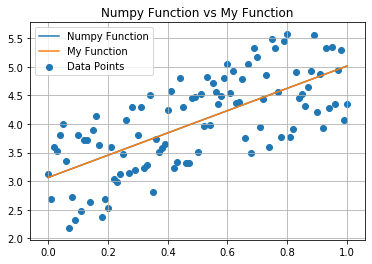

In [10]:
plt.figure()
plt.title('Numpy Function vs My Function')
plt.plot(x, y1, label='Numpy Function')
plt.plot(x, y2, label='My Function')
plt.scatter(x, y, label='Data Points')
plt.legend()
plt.grid(True)
plt.show()

Both functions produced a near-identical fit, producing nearly identical values for m and c with variation only occurring in the last few decimal places, if at all